In [29]:
!pip install ViennaRNA

In [30]:
import numpy as np
import pandas as pd
import time
import subprocess
import RNA

#for hierarchical clustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score


In [31]:
#generate matrix

def generate_mass_like_matrix(m=20, n=40, tau=4, noise=0.05, seed=1):
    np.random.seed(seed)


    cluster_patterns = np.random.randint(0, 2, size=(tau, n)) #create tau cluster patterns
    cluster_assignments = np.random.choice(tau, size=m) #assign each RNA structure to one cluster
    B = cluster_patterns[cluster_assignments].copy() #each structure copies its cluster pattern

    #add small random noise so structures are not identical
    noise_mask = np.random.rand(m, n) < noise
    B[noise_mask] = 1 - B[noise_mask]

    row_names = [f"P{i+1}" for i in range(m)]
    col_names = [f"feature_{j+1}" for j in range(n)]

    df = pd.DataFrame(B, index=row_names, columns=col_names)
    return df, cluster_assignments

B, true_clusters = generate_mass_like_matrix(
    m=20,
    n=40,
    tau=4,
    noise=0.25,
    seed=42
)

print(true_clusters)



[2 0 3 3 1 0 3 2 2 1 3 0 2 3 3 1 2 2 0 2]


In [32]:
def consensus_features(B, threshold=0.7):
    feature_freq = B.mean(axis=0) # Fraction of structures containing each feature

    selected_features = feature_freq[feature_freq >= threshold].index.tolist() # Keep features with frequency >= threshold

    consensus_vector = (feature_freq >= threshold).astype(int) # Binary consensus vector

    return selected_features, consensus_vector, feature_freq

In [33]:
#mass inspired greedy heuristic

def induced_clusters(B, selected_features):
    if not selected_features:
        return [0] * len(B)

    patterns = B[selected_features].astype(str).agg("".join, axis=1)

    cluster_map = {}
    labels = []

    for pattern in patterns:
        if pattern not in cluster_map:
            cluster_map[pattern] = len(cluster_map)
        labels.append(cluster_map[pattern])

    return labels


def greedy_mass(B, tau):

    selected_features = []

    # Sort columns by multiplicity, highest to lowest
    feature_order = B.sum(axis=0).sort_values(ascending=False).index.tolist()

    for feature in feature_order:
        candidate_features = selected_features + [feature]

        labels = induced_clusters(B, candidate_features)
        num_clusters = len(set(labels))

        # Keep feature only if it does not exceed tau clusters
        if num_clusters <= tau:
            selected_features.append(feature)

    final_labels = induced_clusters(B, selected_features)

    return selected_features, final_labels

In [34]:
def run_hierarchical(B, true_clusters, tau):
    model = AgglomerativeClustering(
        n_clusters=tau,
        linkage="ward"
    )

    pred = model.fit_predict(B)
    ari = adjusted_rand_score(true_clusters, pred)

    return pred, ari

#to give consensus cluster labels too
def run_consensus(B, true_clusters, threshold=0.7):
    selected_features, consensus_vector, feature_freq = consensus_features(
        B,
        threshold=threshold
    )

    consensus_pred = induced_clusters(B, selected_features)

    consensus_ari = adjusted_rand_score(true_clusters, consensus_pred)

    return selected_features, consensus_pred, consensus_ari


def run_single_experiment(m, n, tau, noise, seed, consensus_threshold=0.7):
    B, true_clusters = generate_mass_like_matrix(
        m=m,
        n=n,
        tau=tau,
        noise=noise,
        seed=seed
    )

    start = time.time()
    hc_pred, hc_ari = run_hierarchical(B, true_clusters, tau)
    hc_time = time.time() - start

    start = time.time()
    consensus_features_selected, consensus_pred, consensus_ari = run_consensus(
        B,
        true_clusters,
        threshold=consensus_threshold
    )
    consensus_time = time.time() - start

    start = time.time()
    greedy_features, greedy_pred = greedy_mass(B, tau)
    greedy_time = time.time() - start

    greedy_ari = adjusted_rand_score(true_clusters, greedy_pred)

    return {
        "m": m,
        "n": n,
        "tau": tau,
        "noise": noise,
        "seed": seed,

        "HC_ARI": hc_ari,
        "HC_Features": None,
        "HC_Time": hc_time,

        "Consensus_ARI": consensus_ari,
        "Consensus_Features": len(consensus_features_selected),
        "Consensus_Time": consensus_time,

        "Greedy_ARI": greedy_ari,
        "Greedy_Features": len(greedy_features),
        "Greedy_Time": greedy_time
    }

In [35]:
results = []

#testing different sizes(m and n) tau values, and noise levels
noise_settings = [
    (20, 40, 4, 0.05),
    (20, 40, 4, 0.10),
    (20, 40, 4, 0.15),
    (20, 40, 4, 0.20),
    (20, 40, 4, 0.25),
    (20, 40, 4, 0.30),
]

tau_settings = [
    (20, 40, 2, 0.15),
    (20, 40, 3, 0.15),
    (20, 40, 4, 0.15),
    (20, 40, 5, 0.15),
    (20, 40, 6, 0.15),
]

size_settings = [
    (15, 30, 4, 0.15),
    (20, 40, 4, 0.15),
    (25, 50, 4, 0.15),
    (30, 60, 4, 0.15),
]

settings = noise_settings + tau_settings + size_settings
# remove duplicates
settings = list(dict.fromkeys(settings))

for m, n, tau, noise in settings:
    for seed in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
        result = run_single_experiment(
            m=m,
            n=n,
            tau=tau,
            noise=noise,
            seed=seed,
            consensus_threshold=0.7
        )
        results.append(result)

results_df = pd.DataFrame(results)

print(results_df)

      m   n  tau  noise  seed  HC_ARI HC_Features   HC_Time  Consensus_ARI  \
0    20  40    4   0.05     1     1.0        None  0.013316       0.262814   
1    20  40    4   0.05     2     1.0        None  0.002541       0.461021   
2    20  40    4   0.05     3     1.0        None  0.003937       0.583122   
3    20  40    4   0.05     4     1.0        None  0.003937       0.451252   
4    20  40    4   0.05     5     1.0        None  0.004012       0.560889   
..   ..  ..  ...    ...   ...     ...         ...       ...            ...   
125  30  60    4   0.15     6     1.0        None  0.011569       0.044024   
126  30  60    4   0.15     7     1.0        None  0.004125       0.042198   
127  30  60    4   0.15     8     1.0        None  0.008262       0.096456   
128  30  60    4   0.15     9     1.0        None  0.004355       0.036802   
129  30  60    4   0.15    10     1.0        None  0.004338       0.127519   

     Consensus_Features  Consensus_Time  Greedy_ARI  Greedy_Fea

In [36]:
summary = results_df.groupby(["m", "n", "tau", "noise"]).agg({
    "HC_ARI": "mean",
    "Consensus_ARI": "mean",
    "Greedy_ARI": "mean",

    "Consensus_Features": "mean",
    "Greedy_Features": "mean",

    "HC_Time": "mean",
    "Consensus_Time": "mean",
    "Greedy_Time": "mean"
}).reset_index()

print(summary)

     m   n  tau  noise    HC_ARI  Consensus_ARI  Greedy_ARI  \
0   15  30    4   0.15  0.921411       0.152909    0.132622   
1   20  40    2   0.15  1.000000       0.015978    0.022379   
2   20  40    3   0.15  1.000000       0.056472    0.034350   
3   20  40    4   0.05  1.000000       0.415493    0.227295   
4   20  40    4   0.10  1.000000       0.232596    0.165146   
5   20  40    4   0.15  0.964172       0.150151    0.112486   
6   20  40    4   0.20  0.892704       0.140614    0.115988   
7   20  40    4   0.25  0.736650       0.098595    0.091803   
8   20  40    4   0.30  0.416126       0.040537    0.078342   
9   20  40    5   0.15  0.952406       0.197666    0.148430   
10  20  40    6   0.15  0.903004       0.172952    0.174076   
11  25  50    4   0.15  0.991265       0.179580    0.147726   
12  30  60    4   0.15  1.000000       0.063917    0.036462   

    Consensus_Features  Greedy_Features   HC_Time  Consensus_Time  Greedy_Time  
0                  5.5              

<Axes: title={'center': 'Effect of Noise on Clustering Accuracy'}, xlabel='noise'>

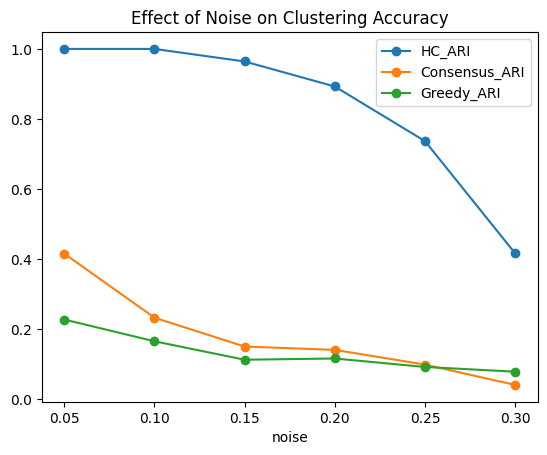

In [37]:
noise_summary = summary[
    (summary["m"] == 20) &
    (summary["n"] == 40) &
    (summary["tau"] == 4)
].sort_values("noise")

noise_summary.plot(
    x="noise",
    y=["HC_ARI", "Consensus_ARI", "Greedy_ARI"],
    marker="o",
    title="Effect of Noise on Clustering Accuracy"
)

<Axes: title={'center': 'Effect of τ on Feature Selection'}, xlabel='tau'>

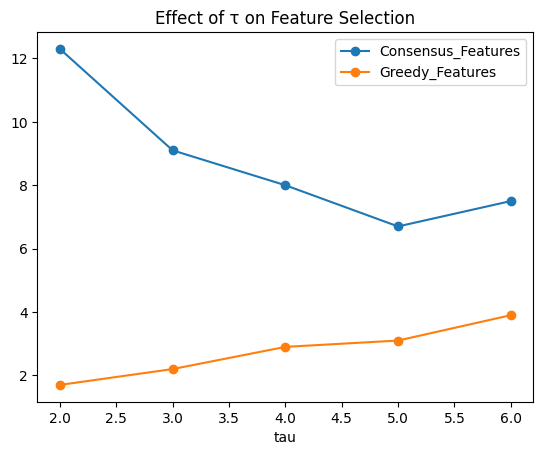

In [38]:
tau_summary = summary[
    (summary["m"] == 20) &
    (summary["n"] == 40) &
    (summary["noise"] == 0.15)
].sort_values("tau")

tau_summary.plot(
    x="tau",
    y=["Consensus_Features", "Greedy_Features"],
    marker="o",
    title="Effect of τ on Feature Selection"
)

<Axes: title={'center': 'Runtime Across Dataset Sizes'}, xlabel='m'>

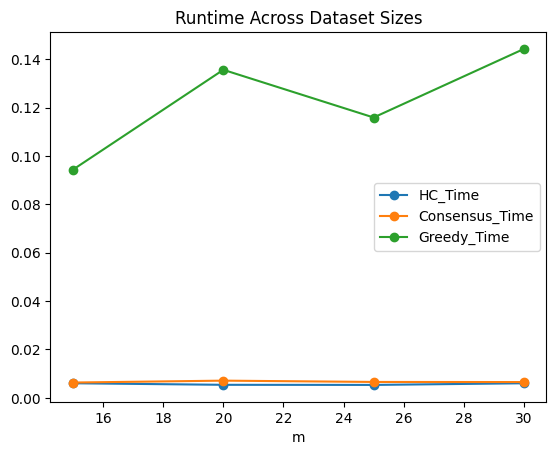

In [39]:
size_summary = summary[
    (summary["tau"] == 4) &
    (summary["noise"] == 0.15)
].sort_values("m")

size_summary.plot(
    x="m",
    y=["HC_Time", "Consensus_Time", "Greedy_Time"],
    marker="o",
    title="Runtime Across Dataset Sizes"
)

RFAM Dataset

In [40]:
#parse sequences from file
def read_stockholm_sequences(filename, max_sequences=20):
    sequences = []

    with open(filename, "r") as file:
        for line in file:
            line = line.strip()

            if not line or line.startswith("#") or line == "//":
                continue

            parts = line.split()

            if len(parts) >= 2:
                name = parts[0]
                seq = parts[1]

                seq = seq.replace("-", "").replace(".", "")

                seq = seq.upper().replace("T", "U")

                if len(seq) > 0:
                    sequences.append((name, seq))

            if len(sequences) >= max_sequences:
                break

    return sequences

def run_rnafold(sequence):
    fc = RNA.fold_compound(sequence)
    structure, mfe = fc.mfe()
    return structure

#conver paranthases to base pairs
def get_base_pairs(dot_bracket):
    stack = []
    pairs = []

    for i, char in enumerate(dot_bracket):
        if char == "(":
            stack.append(i + 1)
        elif char == ")":
            left = stack.pop()
            pairs.append((left, i + 1))

    return set(pairs)


#build binary matrices from structures
def build_binary_matrix_from_structures(structures):
    parsed_pairs = []
    all_features = set()

    for name, dot in structures:
        pairs = get_base_pairs(dot)
        parsed_pairs.append((name, pairs))
        all_features.update(pairs)

    features = sorted(all_features)

    rows = []

    for name, pairs in parsed_pairs:
        row = [1 if feature in pairs else 0 for feature in features]
        rows.append(row)

    B = pd.DataFrame(
        rows,
        index=[name for name, pairs in parsed_pairs],
        columns=[f"bp_{i}_{j}" for i, j in features]
    )

    return B


In [41]:
#run rfam experiemnt and test algorithms
rfam_sequences = read_stockholm_sequences(
    "rfam.txt",
    max_sequences=15
)

structures = []

for name, seq in rfam_sequences:
    dot = run_rnafold(seq)
    structures.append((name, dot))

B_rfam = build_binary_matrix_from_structures(structures)

print("Rfam matrix shape:", B_rfam.shape)
print(B_rfam.head())

tau = 4

hc_pred = AgglomerativeClustering(
    n_clusters=tau,
    linkage="ward"
).fit_predict(B_rfam)

consensus_selected, consensus_vector, feature_freq = consensus_features(B_rfam, threshold=0.7)

greedy_selected, greedy_pred = greedy_mass(B_rfam, tau)

print("Hierarchical clusters:", len(set(hc_pred)))
print("Consensus features selected:", len(consensus_selected))
print("Greedy features selected:", len(greedy_selected))
print("Greedy clusters:", len(set(greedy_pred)))

Rfam matrix shape: (15, 214)
                        bp_1_70  bp_1_71  bp_1_72  bp_1_73  bp_1_81  bp_1_85  \
AB003409.1/96-167             0        1        0        0        0        0   
AB009835.1/1-71               1        0        0        0        0        0   
AB013372.1/8-81               0        0        0        1        0        0   
AB013373.1/3754-3825          0        1        0        0        0        0   
AB017063.1/58819-58900        0        0        0        0        1        0   

                        bp_2_69  bp_2_70  bp_2_71  bp_2_72  ...  bp_52_62  \
AB003409.1/96-167             0        1        0        0  ...         0   
AB009835.1/1-71               1        0        0        0  ...         0   
AB013372.1/8-81               0        0        0        1  ...         0   
AB013373.1/3754-3825          0        1        0        0  ...         0   
AB017063.1/58819-58900        0        0        0        0  ...         0   

                        bp_

In [42]:
#try lower consensus thresholds
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    consensus_selected = consensus_features(B_rfam, threshold=threshold)[0]
    print(threshold, len(consensus_selected))

0.3 5
0.4 0
0.5 0
0.6 0
0.7 0


In [43]:
#beam search
def beam_search_mass(B, tau, beam_width=5, max_steps=20):
    """
    Beam search version of the greedy MASS heuristic.

    Keeps the top beam_width feature sets at each step instead of only one.
    """

    all_features = list(B.columns)

    # Start with no selected features
    beam = [([], (0, 0))]
    best_features = []
    best_score = (0, 0)

    for step in range(max_steps):
        candidates = []

        for selected_features, old_score in beam:
            remaining_features = [
                feature for feature in all_features
                if feature not in selected_features
            ]

            for feature in remaining_features:
                candidate_features = selected_features + [feature]

                labels = induced_clusters(B, candidate_features)
                num_clusters = len(set(labels))

                if num_clusters <= tau:
                    # more selected features, more induced clusters, up to tau
                    score = (len(candidate_features), num_clusters)

                    candidates.append((candidate_features, score))

        if len(candidates) == 0:
            break

        # remove duplicate feature sets
        unique = {}
        for features, score in candidates:
            key = tuple(sorted(features))
            if key not in unique or score > unique[key][1]:
                unique[key] = (features, score)

        candidates = list(unique.values())

        # keep top beam width candidates
        candidates.sort(key=lambda x: x[1], reverse=True)
        beam = candidates[:beam_width]

        if beam[0][1] > best_score:
            best_features = beam[0][0]
            best_score = beam[0][1]

    final_labels = induced_clusters(B, best_features)

    return best_features, final_labels

tau = 4

beam_features, beam_pred = beam_search_mass(
    B_rfam,
    tau=tau,
    beam_width=5,
    max_steps=30
)

print("Beam features selected:", len(beam_features))
print("Beam clusters:", len(set(beam_pred)))

tau = 4

# consensus
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    consensus_selected = consensus_features(B_rfam, threshold=threshold)[0]
    print("Consensus threshold:", threshold)
    print("Consensus features selected:", len(consensus_selected))
    print()

# greedy
greedy_features, greedy_pred = greedy_mass(B_rfam, tau)

print("Greedy features selected:", len(greedy_features))
print("Greedy clusters:", len(set(greedy_pred)))

# beam search
beam_features, beam_pred = beam_search_mass(
    B_rfam,
    tau=tau,
    beam_width=5,
    max_steps=30
)

print("Beam features selected:", len(beam_features))
print("Beam clusters:", len(set(beam_pred)))

Beam features selected: 15
Beam clusters: 4
Consensus threshold: 0.3
Consensus features selected: 5

Consensus threshold: 0.4
Consensus features selected: 0

Consensus threshold: 0.5
Consensus features selected: 0

Consensus threshold: 0.6
Consensus features selected: 0

Consensus threshold: 0.7
Consensus features selected: 0

Greedy features selected: 25
Greedy clusters: 4
Beam features selected: 15
Beam clusters: 4
